# Reference solution — Project 03 (final): Income prediction on real census data

Fully executed solution for `../income_prediction.ipynb`. Try it yourself first!

## 1. Load and explore the data

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

data = fetch_openml(name="adult", version=2, as_frame=True)
df = data.frame

print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])
print(df["class"].value_counts(normalize=True))

(48842, 15)
workclass         2799
occupation        2809
native-country     857
dtype: int64
class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


## 2. Preparation: target variable and features

In [2]:
y = (df["class"] == ">50K").astype(int)
X = df.drop(columns=["class", "fnlwgt", "education"])

numerical_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                        "race", "sex", "native-country"]

print(f"Number of features: {len(numerical_features) + len(categorical_features)}")
print(y.mean())

Number of features: 12
0.23928176569346055


## 3. Train/test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)}, test: {len(X_test)}")
print(abs(y_test.mean() - y.mean()) < 0.01)

Training: 39073, test: 9769
True


## 4. Preprocessing pipeline

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessing = ColumnTransformer([
    ("num", numeric_pipe, numerical_features),
    ("cat", categorical_pipe, categorical_features),
])

print(preprocessing)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'marital-status', 'occupation',
                                  'relationship', 'race', 'sex',
                 

## 5. Baseline

In [5]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Dummy accuracy: {dummy.score(X_test, y_test):.3f}  (simply always predicts '<=50K')")

Dummy accuracy: 0.761  (simply always predicts '<=50K')


## 6. Model comparison under class imbalance

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([("prep", preprocessing),
                                     ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", preprocessing),
                               ("clf", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
    "Gradient Boosting": Pipeline([("prep", preprocessing),
                                   ("clf", HistGradientBoostingClassifier(random_state=42, class_weight="balanced"))]),
}

results = {}
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    results[name] = scores

for name, scores in results.items():
    print(f"{name:25s}  PR-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression        PR-AUC = 0.7613 +/- 0.0114
Random Forest              PR-AUC = 0.7327 +/- 0.0089
Gradient Boosting          PR-AUC = 0.8265 +/- 0.0072


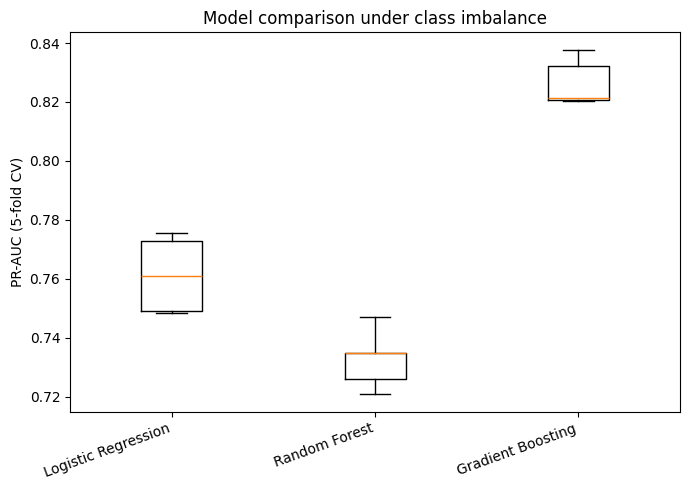

In [7]:
plt.figure(figsize=(7, 5))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.xticks(rotation=20, ha="right")
plt.ylabel("PR-AUC (5-fold CV)")
plt.title("Model comparison under class imbalance")
plt.tight_layout()
plt.show()

## 7. Tuning the best model

Gradient boosting usually comes out on top — tuned here.

In [8]:
from sklearn.model_selection import GridSearchCV

grid = {
    "clf__max_iter": [100, 200, 300],
    "clf__learning_rate": [0.03, 0.1, 0.2],
    "clf__max_leaf_nodes": [15, 31, 63],
}
search = GridSearchCV(models["Gradient Boosting"], grid, cv=cv, scoring="average_precision", n_jobs=-1)
search.fit(X_train, y_train)

print(f"Best CV PR-AUC: {search.best_score_:.4f}")
print(f"Best parameters: {search.best_params_}")

Best CV PR-AUC: 0.8272
Best parameters: {'clf__learning_rate': 0.1, 'clf__max_iter': 200, 'clf__max_leaf_nodes': 15}


## 8. The one-off test evaluation

              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      7431
        >50K       0.60      0.87      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.84      0.80      9769
weighted avg       0.87      0.83      0.84      9769

Test PR-AUC: 0.8293


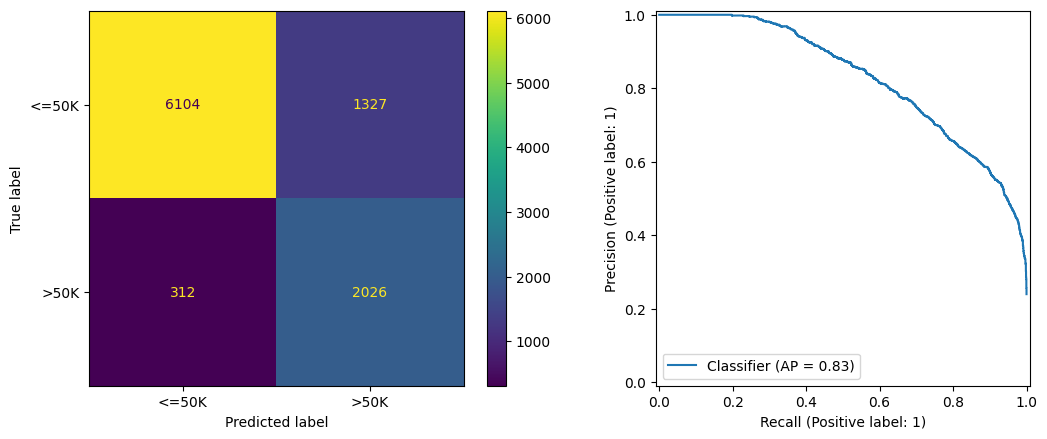

In [9]:
from sklearn.metrics import (classification_report, PrecisionRecallDisplay,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay)

best_model = search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_05, target_names=["<=50K", ">50K"]))
print(f"Test PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_05, display_labels=["<=50K", ">50K"], ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
plt.tight_layout()
plt.show()

## 9. Choosing a threshold by a cost calculation

The 0.5 threshold is a convention, not a necessity (script 2.6/3.2). Scenario: an
outreach programme for financial advice wants to address people with an income of
`>50K`. A **false alarm** (FP: contacted, but actually `<=50K`) costs **50 dollars**
(wasted effort). A **missed case** (FN: `>50K`, but not contacted) costs **200 dollars**
(lost business) — four times as expensive as a false alarm.

**Task:** For a grid of thresholds (`np.linspace(0.01, 0.99, 99)`), compute the number
of FP and FN on the test set (from `y_proba`) and from those the total cost
`50 * FP + 200 * FN`. Find the cost-minimal threshold and compare it with 0.5.

Cost-minimal threshold: 0.44  (cost at 0.5: 128750 $, minimal cost: 124000 $)


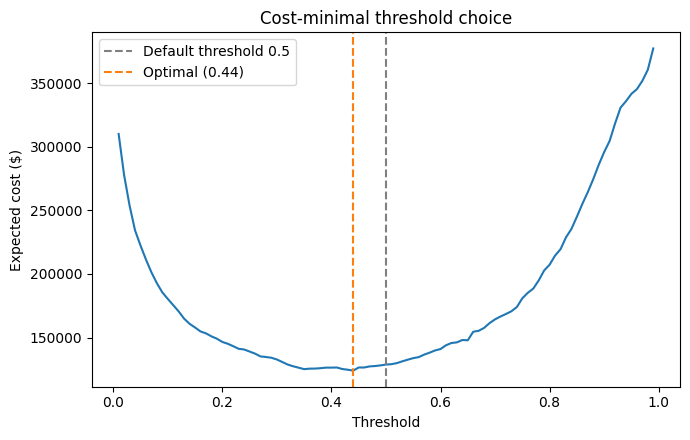

In [10]:
thresholds = np.linspace(0.01, 0.99, 99)
cost_fp, cost_fn = 50, 200

y_test_np = y_test.to_numpy()
costs = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    fp = ((y_pred_t == 1) & (y_test_np == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test_np == 1)).sum()
    costs.append(cost_fp * fp + cost_fn * fn)

best_threshold = thresholds[np.argmin(costs)]
print(f"Cost-minimal threshold: {best_threshold:.2f}  (cost at 0.5: {costs[49]:.0f} $, "
      f"minimal cost: {min(costs):.0f} $)")

plt.figure(figsize=(7, 4.5))
plt.plot(thresholds, costs)
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold 0.5")
plt.axvline(best_threshold, color="C1", linestyle="--", label=f"Optimal ({best_threshold:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Expected cost ($)")
plt.legend(); plt.title("Cost-minimal threshold choice")
plt.tight_layout()
plt.show()

**Discussion:** The cost-minimal threshold lies at about 0.44 — that is, below 0.5,
because a missed case (FN) is four times as expensive as a false alarm (FP). The cost
calculation therefore "rewards" a more generous (lower) threshold that finds more true
positives and accepts more false alarms in return. `class_weight="balanced"` balances
the class frequencies in the loss function during **training** (it prevents the model
from ignoring the rare class) and has thereby already shifted the scores towards the
rare class — which is why the additional correction by the cost threshold turns out to
be comparatively moderate here. It nevertheless remains a different problem from the
**decision threshold**, which is applied only after training, on the scores that have
already been learned, and which reflects the concrete cost asymmetry of the
application. Both are needed together; neither replaces the other.

## 10. Fairness check: error rates by sex

The data set contains `sex` as a feature — the model therefore has direct or indirect
(via correlated features) access to it. **Task:** At the cost-minimal threshold from
step 9, compute recall and false positive rate on the test set separately for both
groups (`Male`, `Female`) and put them side by side.

In [11]:
y_pred_final = (y_proba >= best_threshold).astype(int)
fairness_rows = []
for group in X_test["sex"].unique():
    mask = (X_test["sex"] == group).to_numpy()
    tp = ((y_pred_final == 1) & (y_test_np == 1) & mask).sum()
    fn = ((y_pred_final == 0) & (y_test_np == 1) & mask).sum()
    fp = ((y_pred_final == 1) & (y_test_np == 0) & mask).sum()
    tn = ((y_pred_final == 0) & (y_test_np == 0) & mask).sum()
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fairness_rows.append({"Group": group, "n": mask.sum(), "Base rate >50K": y_test_np[mask].mean(),
                          "Recall": recall, "FPR": fpr})

pd.DataFrame(fairness_rows)

,Group,n,Base rate >50K,Recall,FPR
0,Female,3259,0.110770,0.797784,0.074189
1,Male,6510,0.303687,0.911482,0.280829


**Discussion:** The base rate of `>50K` differs strongly between the groups (a
historically caused gender pay gap in the 1994 census data), and recall typically also
comes out lower for the group with the lower base rate — the model "finds" rarer
positive cases with more difficulty, a well-known pattern with imbalanced subgroups.
Part of the gap is therefore explained by the different base rate, but the difference in
how errors are distributed should nevertheless count as a warning signal before the
model is put into operation (for instance to allocate access to financial advice) —
here one would need an explicit fairness metric (e.g. equal opportunity: the same recall
per group) and possibly group-specific thresholds or a fairness constraint during
training, not just a global cost threshold.

## 11. Permutation importance

**Task:** Compute `permutation_importance` for `best_model` **directly on the raw test
features** `X_test` (the pipeline handles the preprocessing internally — this way you
get importances per **original column**, not per one-hot dummy). Plot all features as a
horizontal bar chart.

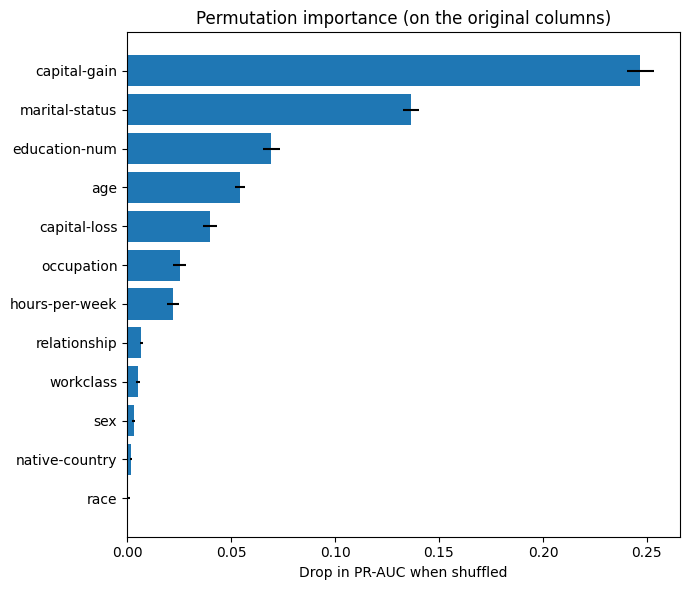

In [12]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(best_model, X_test, y_test,
                                    n_repeats=15, random_state=42, scoring="average_precision")

order = np.argsort(importance.importances_mean)
plt.figure(figsize=(7, 6))
plt.barh(X_test.columns[order], importance.importances_mean[order],
         xerr=importance.importances_std[order])
plt.xlabel("Drop in PR-AUC when shuffled")
plt.title("Permutation importance (on the original columns)")
plt.tight_layout()
plt.show()

**Discussion:** `capital-gain`, `education-num`, `age`, `hours-per-week` and
`marital-status` typically come out on top — plausible (capital income, education, work
experience and working hours correlate with income). `sex` often carries only little
direct model importance, which according to step 10 does **not** mean that there is no
fairness gap: the information can enter via correlated proxy features (`relationship`,
`occupation`, `marital-status`) without `sex` itself being ranked highly — a classic
example of why feature importance and fairness are two separate questions (script 3.1:
model usage is not causality, and here additionally not fairness).

## Done — what you can do now

- Carry out a complete, realistic ML project end to end: mixed types, missing values,
  class imbalance
- Use `ColumnTransformer` for heterogeneous preprocessing inside one pipeline
- Compare models fairly under imbalance (PR-AUC instead of accuracy)
- Choose a decision threshold **by costs**, not by convention
- Check a model for **fairness between subgroups** before it is deployed
- Interpret importances at the level of the original features

**Reflection questions — reference answers:**

1. `class_weight="balanced"` only makes sure that both classes count equally in the
   **training loss** — it does not guarantee that the **error rates between demographic
   subgroups** (not target classes!) are equalised. These are two orthogonal balance
   problems.
2. No, probably not reliably: features such as `relationship` (e.g. "Wife"/"Husband"),
   `occupation` or `marital-status` correlate strongly with `sex` and can carry its
   information indirectly (proxy discrimination) — removing the feature solves the
   problem on the surface, but not structurally.
3. The 1994 data reflect the labour market structure, the wage inequalities and the
   social norms of that time. A model deployed today would perpetuate outdated (and
   partly discriminatory) patterns, even though the labour market, job profiles and
   incomes have changed since — a core risk of "historical bias" in operational ML.